# Prepare Dataset

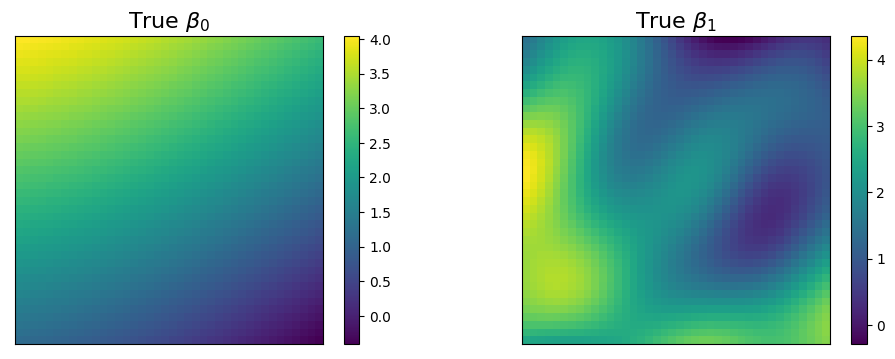

In [2]:
import numpy as np
from mgwr.gwr import GWR as OfficialGWR
from mgwr.sel_bw import Sel_BW
from src.log.gwr_logger import GwrLogger
from src.kernel.gwr_kernel import GwrKernel
from src.model.gwr import GWR
from src.dataset.simulated_spatial_dataset import SimulatedSpatialDataset
from src.model.lgwr import LGWR
from src.kernel.lgwr_kernel import LgwrKernel

k = 1
field_size = 40
dataset = SimulatedSpatialDataset(
    k=k,
    field_size=field_size,
    process_seed=[666, 888],
    len_scale_seed=[100, 10]
)
[X] = dataset.generate_data()
[beta] = dataset.generate_processes()
[y, err] = dataset.fit_y(
    X, beta
)

dataset.plot(
    b=np.vstack([
        beta.T
    ]),
    sub_title=[
        r"True $\beta_0$",
        r"True $\beta_1$"
    ],
    size=field_size
)

# Find the global optimal bandwidth using golden section search

In [3]:
g_X = dataset.X[:, 1:]
g_y = dataset.y.reshape(-1, 1)
g_coords = dataset.coordinates.tolist()
gwr_selector = Sel_BW(
    g_coords, 
    g_y, 
    g_X
)
global_optimal_bandwidth = gwr_selector.search(bw_min=2)
official_gwr = OfficialGWR(
    g_coords, 
    g_y, 
    g_X, 
    global_optimal_bandwidth
).fit()

In [4]:
# nicely formatted comparison of the official GWR fit
line_width = 60
col1_w = 30
col2_w = line_width - col1_w
print("=" * line_width)
print("GWR Model".center(line_width))
print("=" * line_width)
print(f"{'Metric':{col1_w}}{ 'Official GWR':>{col2_w}}")
print("-" * line_width)
print(f"{'Global bandwidth':{col1_w}}{int(global_optimal_bandwidth):{col2_w}d}")
print(f"{'R-squared':{col1_w}}{official_gwr.R2:{col2_w}.4f}")
print(f"{'AIC':{col1_w}}{official_gwr.aic:{col2_w}.2f}")
print(f"{'AICc':{col1_w}}{official_gwr.aicc:{col2_w}.2f}")
print("=" * line_width)

                         GWR Model                          
Metric                                          Official GWR
------------------------------------------------------------
Global bandwidth                                         103
R-squared                                             0.8684
AIC                                                  4555.78
AICc                                                 4565.68


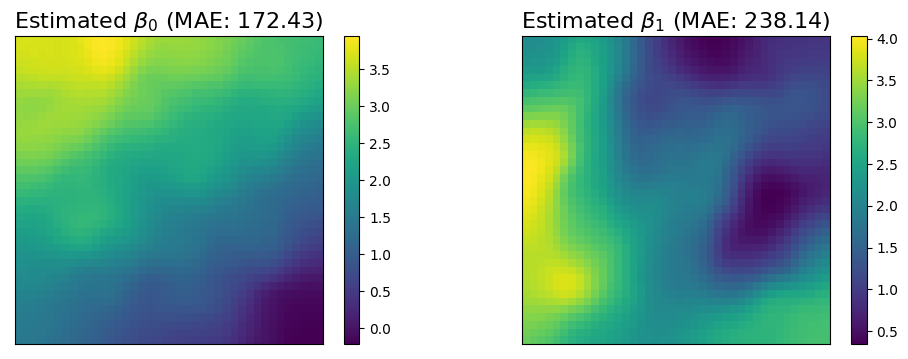

In [5]:
est = np.asarray(official_gwr.params)
true = np.asarray(beta)
mae_per_coef = np.sum(np.abs(est - true), axis=0)


dataset.plot(
    b=np.vstack([
        official_gwr.params.T
    ]),
    sub_title=[
        r"Estimated $\beta_0$ (MAE: {:.2f})".format(mae_per_coef[0]),
        r"Estimated $\beta_1$ (MAE: {:.2f})".format(mae_per_coef[1])
    ],
    size=field_size
)

# Construct the LGWR model using uniform bandwidth

In [6]:
kernel = LgwrKernel(
    dataset,
    kernel_type='bisquare',
    kernel_bandwidth_type='adaptive'
)
lgwr = LGWR(dataset, kernel)

In [7]:
# fit the LGWR model with the global optimal bandwidth
lgwr = lgwr.update_local_bandwidth_vector(
    np.full(dataset.n, global_optimal_bandwidth)
).fit()

In [8]:
# nicely formatted comparison of the official GWR fit
line_width = 60
col1_w = 30
col2_w = line_width - col1_w
print("=" * line_width)
print("GWR Model".center(line_width))
print("=" * line_width)
print(f"{'Metric':{col1_w}}{ 'Official GWR':>{col2_w}}")
print("-" * line_width)
print(f"{'Global bandwidth':{col1_w}}{int(global_optimal_bandwidth):{col2_w}d}")
print(f"{'R-squared':{col1_w}}{lgwr.r_squared:{col2_w}.4f}")
print(f"{'AIC':{col1_w}}{lgwr.aic:{col2_w}.2f}")
print(f"{'AICc':{col1_w}}{lgwr.aicc:{col2_w}.2f}")
print("=" * line_width)

                         GWR Model                          
Metric                                          Official GWR
------------------------------------------------------------
Global bandwidth                                         103
R-squared                                             0.8684
AIC                                                  4555.78
AICc                                                 4565.68


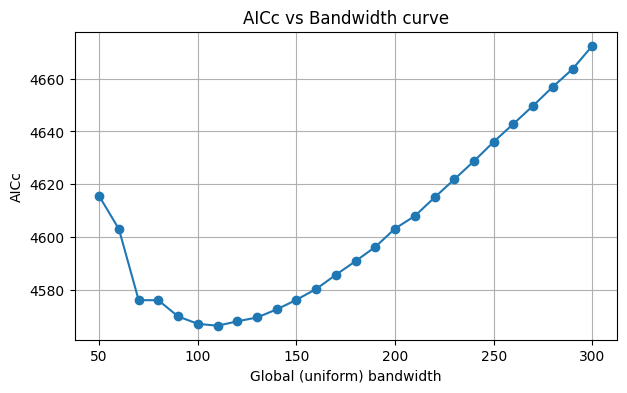

In [9]:
# Draw AICc vs global bandwidth curve

import matplotlib.pyplot as plt
bandwidths = np.arange(50, 301, 10)
aicc_values = []

for bw in bandwidths:
    lgwr.update_local_bandwidth_vector(np.full(dataset.n, bw))
    lgwr.fit()
    aicc_values.append(lgwr.aicc)


plt.figure(figsize=(7, 4))
plt.plot(bandwidths, aicc_values, marker='o')
plt.xlabel("Global (uniform) bandwidth")
plt.ylabel("AICc")
plt.title("AICc vs Bandwidth curve")
plt.grid(True)
plt.show()

# Local bandwidth adjustment for random points

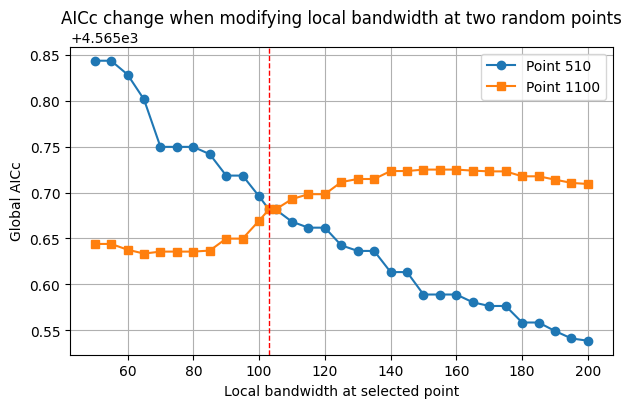

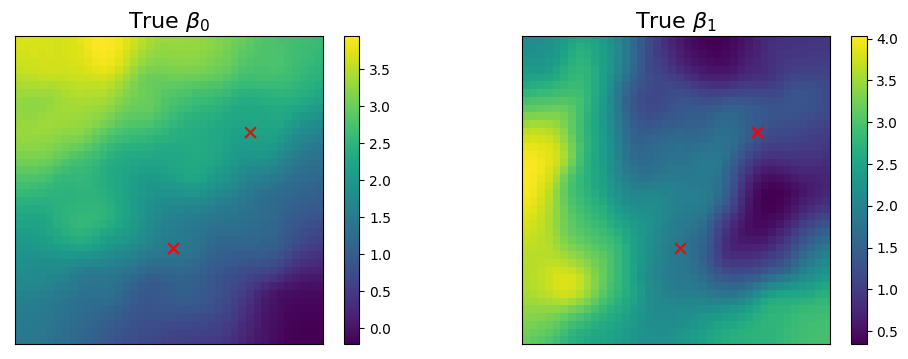

In [20]:
idx1, idx2 = 510, 1100
bandwidths = np.arange(50, 201, 5)
bandwidths = np.sort(np.append(bandwidths, global_optimal_bandwidth))
aicc_curve_1 = []
aicc_curve_2 = []
base_bw = np.full(dataset.n, global_optimal_bandwidth)

for bw in bandwidths:
    bw_vec = base_bw.copy()
    bw_vec[idx1] = bw
    lgwr.update_local_bandwidth_vector(bw_vec)
    lgwr.fit()
    aicc_curve_1.append(lgwr.aicc)

for bw in bandwidths:
    bw_vec = base_bw.copy()
    bw_vec[idx2] = bw
    lgwr.update_local_bandwidth_vector(bw_vec)
    lgwr.fit()
    aicc_curve_2.append(lgwr.aicc)

lgwr = lgwr.update_local_bandwidth_vector(
    np.full(dataset.n, global_optimal_bandwidth)
).fit()

plt.figure(figsize=(7, 4))
plt.plot(bandwidths, aicc_curve_1, marker='o', label=f"Point {idx1}")
plt.plot(bandwidths, aicc_curve_2, marker='s', label=f"Point {idx2}")
plt.axvline(global_optimal_bandwidth, color='red', linestyle='--', linewidth=1)
plt.xlabel("Local bandwidth at selected point")
plt.ylabel("Global AICc")
plt.title("AICc change when modifying local bandwidth at two random points")
plt.legend()
plt.grid(True)
plt.show()

dataset.plot(
    b=np.vstack([
        lgwr.betas.T
    ]),
    sub_title=[
        r"True $\beta_0$",
        r"True $\beta_1$"
    ],
    size=field_size,
    points=[idx1, idx2]
)

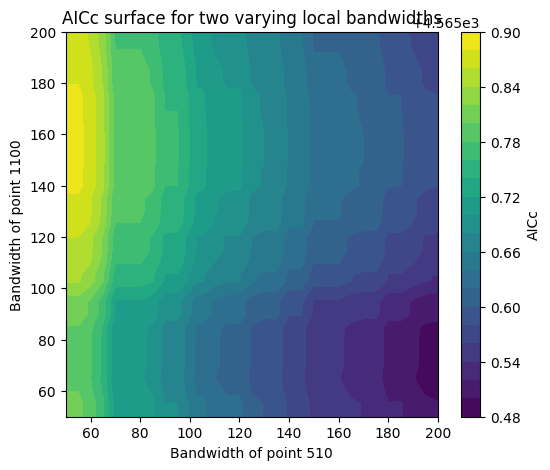

In [21]:
import numpy as np
import matplotlib.pyplot as plt

bw_range = np.arange(50, 201, 5)
bw_range = np.sort(np.append(bw_range, global_optimal_bandwidth))
aicc_surface = np.zeros((len(bw_range), len(bw_range)))

base_bw = np.full(dataset.n, global_optimal_bandwidth)

for i, bw1 in enumerate(bw_range):
    for j, bw2 in enumerate(bw_range):
        bw_vec = base_bw.copy()
        bw_vec[idx1] = bw1
        bw_vec[idx2] = bw2
        lgwr.update_local_bandwidth_vector(bw_vec)
        lgwr.fit()
        aicc_surface[i, j] = lgwr.aicc

plt.figure(figsize=(6, 5))
plt.contourf(bw_range, bw_range, aicc_surface.T, levels=20, cmap="viridis")
plt.xlabel(f"Bandwidth of point {idx1}")
plt.ylabel(f"Bandwidth of point {idx2}")
plt.title("AICc surface for two varying local bandwidths")
plt.colorbar(label="AICc")
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def pick_local_bandwidths_exhaustive(
    lgwr,
    n_points: int,
    candidate_bws=None,
    init_global_bw: float = 100,
):

    if candidate_bws is None:
        candidate_bws = np.arange(50, 201, 5)
    candidate_bws = np.asarray(candidate_bws, dtype=int)

    base_vec = np.full(n_points, init_global_bw, dtype=int)
    lgwr.update_local_bandwidth_vector(base_vec)
    lgwr.fit()

    best_bw = base_vec.copy()

    for i in range(n_points):
        aicc_min = np.inf
        bw_min = base_vec[i]

        for j, bw in enumerate(candidate_bws):
            vec = base_vec.copy()
            vec[i] = int(bw)
            lgwr.update_local_bandwidth_vector(vec)
            lgwr.fit()
            aicc = float(lgwr.aicc)

            if aicc < aicc_min:
                aicc_min = aicc
                bw_min = bw

        best_bw[i] = bw_min


    return best_bw


candidate_bws = np.arange(50, 201, 5) 
final_bw = pick_local_bandwidths_exhaustive(
    lgwr=lgwr,
    n_points=dataset.n,
    candidate_bws=candidate_bws,
    init_global_bw=global_optimal_bandwidth
)
np.savetxt("final_local_bandwidths.txt", final_bw, fmt="%d")


